<a href="https://colab.research.google.com/github/mariemshrief28-prog/Machine-Learning-projects/blob/main/Boston_House_Pricing_ML_vs_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('HousingData.csv')

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


<Axes: >

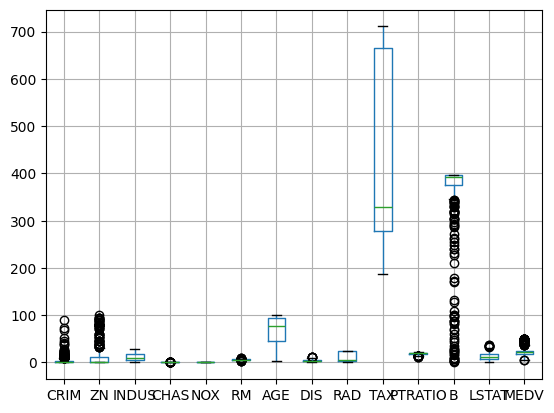

In [ ]:
df.boxplot()

In [ ]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.191178,0.401863,-0.054355,0.417130,-0.219150,0.354342,-0.374166,0.624765,0.580595,0.281110,-0.381411,0.444943,-0.391363
ZN,-0.191178,1.000000,-0.531871,-0.037229,-0.513704,0.320800,-0.563801,0.656739,-0.310919,-0.312371,-0.414046,0.171303,-0.414193,0.373136
INDUS,0.401863,-0.531871,1.000000,0.059859,0.764866,-0.390234,0.638431,-0.711709,0.604533,0.731055,0.390954,-0.360532,0.590690,-0.481772
CHAS,-0.054355,-0.037229,0.059859,1.000000,0.075097,0.104885,0.078831,-0.093971,0.001468,-0.032304,-0.111304,0.051264,-0.047424,0.181391
NOX,0.417130,-0.513704,0.764866,0.075097,1.000000,-0.302188,0.731548,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.582641,-0.427321
RM,-0.219150,0.320800,-0.390234,0.104885,-0.302188,1.000000,-0.247337,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.614339,0.695360
AGE,0.354342,-0.563801,0.638431,0.078831,0.731548,-0.247337,1.000000,-0.744844,0.458349,0.509114,0.269226,-0.275303,0.602891,-0.394656
DIS,-0.374166,0.656739,-0.711709,-0.093971,-0.769230,0.205246,-0.744844,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.493328,0.249929
RAD,0.624765,-0.310919,0.604533,0.001468,0.611441,-0.209847,0.458349,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.479541,-0.381626
TAX,0.580595,-0.312371,0.731055,-0.032304,0.668023,-0.292048,0.509114,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.536110,-0.468536


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
x=df.drop('MEDV', axis=1)
y=df['MEDV']

In [ ]:
for cols in x.columns:
  Q1= x[cols].quantile(.25)
  Q3= x[cols].quantile(.75)

  iqr= Q3-Q1
  upper= Q3 + 2*iqr
  lower= Q1 - 2*iqr

  x[cols]=x[cols].loc[(x[cols]>lower)&(x[cols]<upper)]

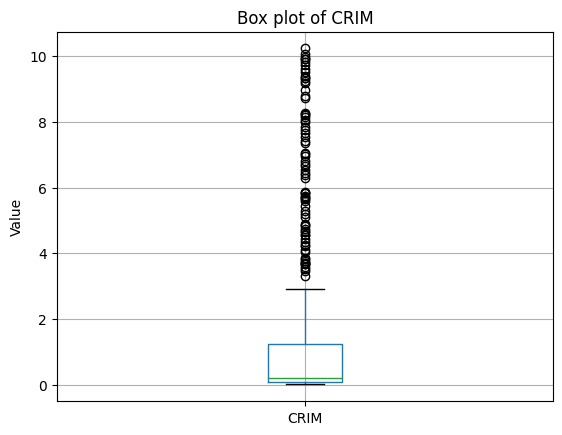

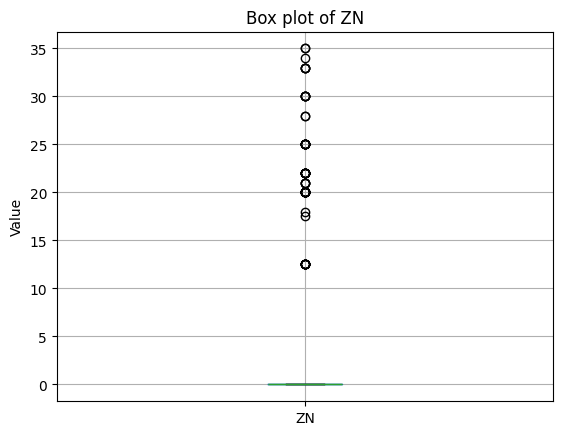

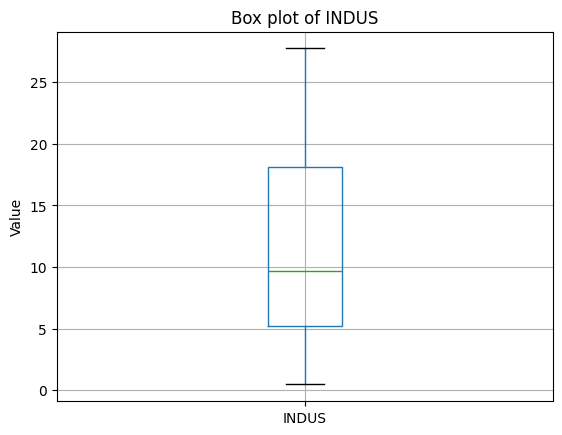

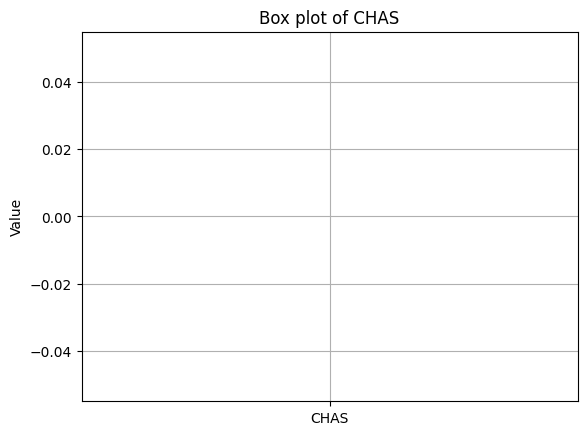

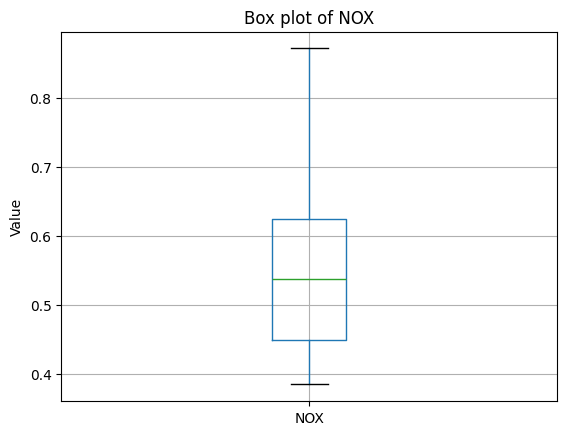

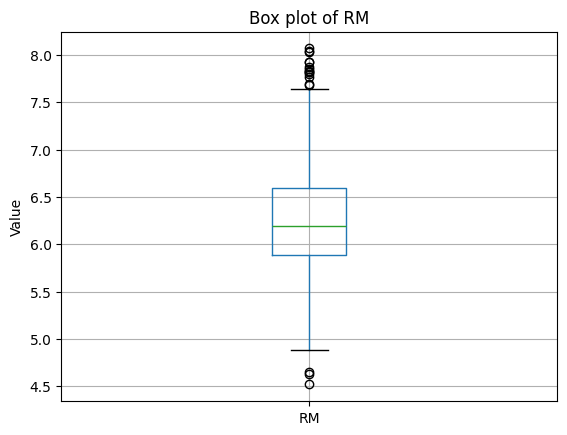

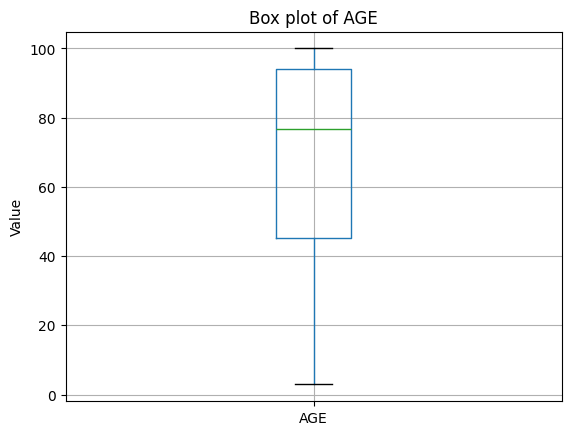

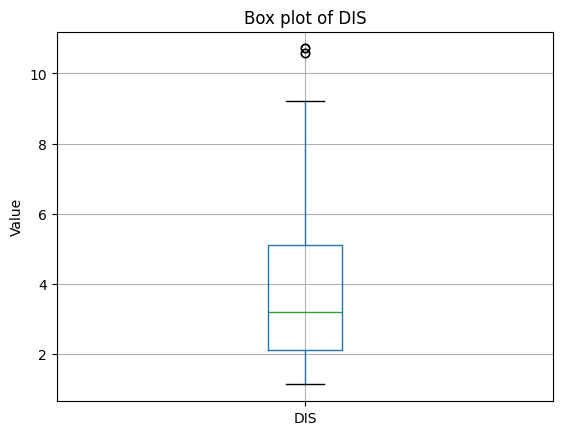

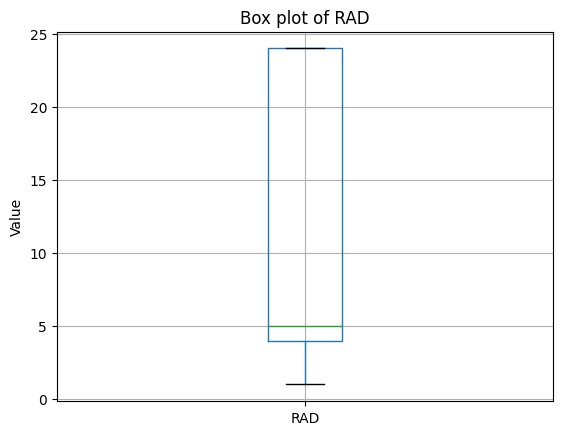

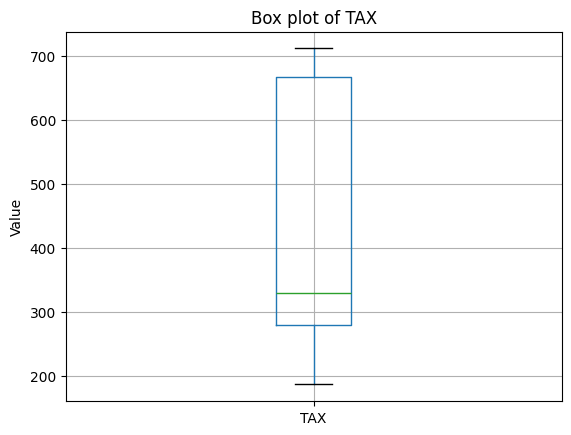

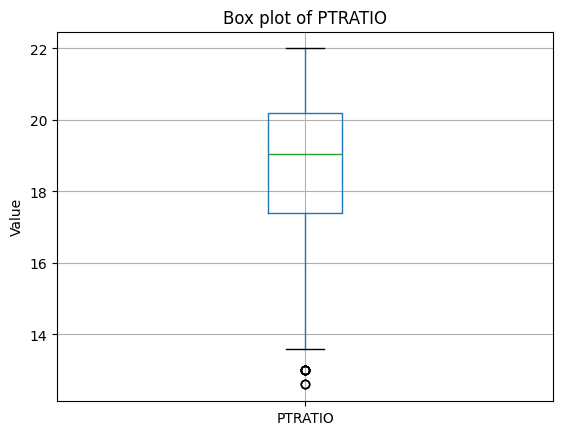

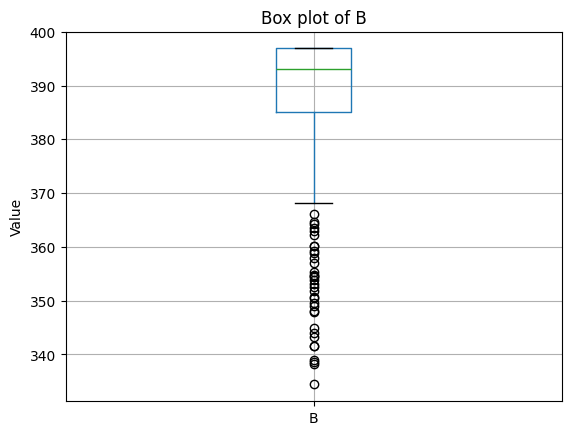

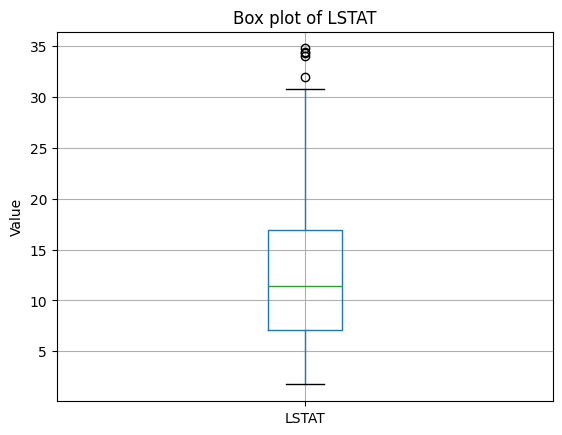

In [ ]:
for cols in x.columns:
  x.boxplot(column=cols)
  plt.title(f'Box plot of {cols}')
  plt.ylabel('Value')
  plt.show()

In [ ]:
x.drop(['CHAS','B'], axis=1, inplace=True)
for cols in x.columns:
  x[cols ]= x[cols].fillna(x[cols].mean())

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      506 non-null    float64
 4   RM       506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    int64  
 8   TAX      506 non-null    int64  
 9   PTRATIO  506 non-null    float64
 10  LSTAT    506 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 43.6 KB


In [ ]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()

cols=x.columns

x[cols]=st.fit_transform(x[cols])

print(x.head())

       CRIM        ZN     INDUS       NOX        RM       AGE       DIS  \
0 -0.608768  1.824240 -1.311010 -0.144217  0.527348 -0.121059  0.150411   
1 -0.599858 -0.459195 -0.599771 -0.740262  0.266311  0.378716  0.573987   
2 -0.599867 -0.459195 -0.599771 -0.740262  1.561324 -0.270627  0.573987   
3 -0.597710 -0.459195 -1.330435 -0.835284  1.244351 -0.828770  1.102842   
4 -0.582140 -0.459195 -1.330435 -0.835284  1.496912 -0.522338  1.102842   

        RAD       TAX   PTRATIO         LSTAT  
0 -0.982843 -0.666608 -1.459000 -1.117607e+00  
1 -0.867883 -0.987329 -0.303094 -5.085184e-01  
2 -0.867883 -0.987329 -0.303094 -1.256701e+00  
3 -0.752922 -1.106115  0.113032 -1.416294e+00  
4 -0.752922 -1.106115  0.113032  2.600861e-16  


In [ ]:

'''
for cols in x.columns:

  plt.hist(x[cols])
  plt.title(f"Diagram {cols}")
  plt.xlabel(cols)
  plt.ylabel("Frequency")
  plt.show()
'''

'\nfor cols in x.columns:\n\n  plt.hist(x[cols])\n  plt.title(f"Diagram {cols}")\n  plt.xlabel(cols)\n  plt.ylabel("Frequency")\n  plt.show()\n'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold

x_train,x_test,y_train,y_test= train_test_split(x,
                                                y,
                                                train_size=.8,
                                                random_state=40)




In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

model = LinearRegression()
model.fit(x_train, y_train)

model_2=DecisionTreeRegressor()
model_2.fit(x_train, y_train)

DecisionTreeRegressor()

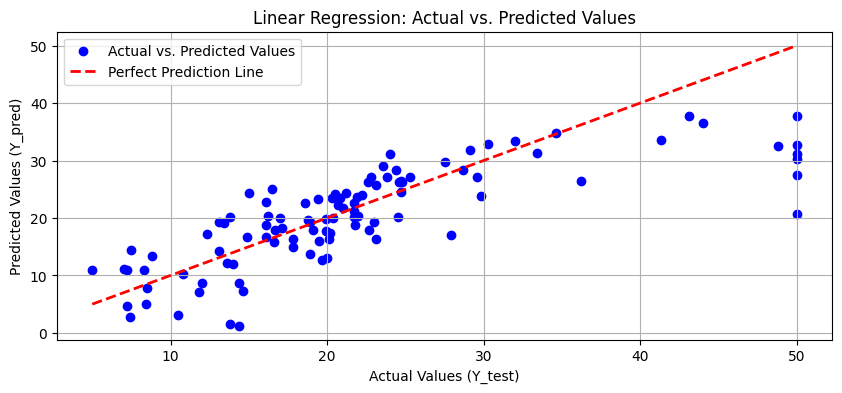

In [ ]:
Y_pred = model.predict(x_test)
plt.figure(figsize=(10,4))
plt.scatter(y_test, Y_pred, color='blue', label='Actual vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae=mean_absolute_error(y_test, Y_pred)
r2= r2_score(y_test, Y_pred)

print(mae, r2)

4.787760769007049 0.5811230412153758


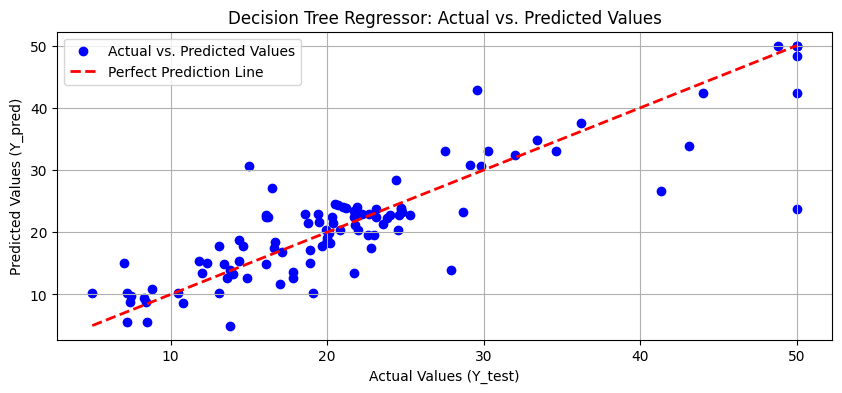

In [ ]:
Y_pred = model_2.predict(x_test)
plt.figure(figsize=(10,4))
plt.scatter(y_test, Y_pred, color='blue', label='Actual vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Decision Tree Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

mae=mean_absolute_error(y_test, Y_pred)
r2= r2_score(y_test, Y_pred)

print(mae, r2)

3.3852941176470583 0.7619829618839968


# NN

In [ ]:
import torch
import numpy as np

In [ ]:
x_num=x.to_numpy()
y_num=y.to_numpy()
X=torch.from_numpy(x_num).type(torch.float32)
Y=torch.from_numpy(y_num).type(torch.float32)

In [ ]:

Y.squeeze().size()

torch.Size([506])

In [ ]:
X.size()

torch.Size([506, 11])

In [ ]:
from torch import nn

In [ ]:
model=nn.Sequential(nn.Linear(in_features=11,out_features=8),
                    nn.ReLU(),
                    nn.Linear(in_features=8,out_features=16),
                    nn.ReLU(),
                    nn.Linear(in_features=16,out_features=32),
                    nn.ReLU(),
                    nn.Linear(in_features=32,out_features=16),
                    nn.ReLU(),
                    nn.Linear(in_features=16,out_features=8),
                    nn.ReLU(),
                    nn.Linear(in_features=8,out_features=1))

In [ ]:
epochs=1000
n_epoch=[]
loss_train=[]
loss_test=[]
loss_fun=nn.MSELoss()
opt=torch.optim.Adam(params=model.parameters(),lr=0.001)

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.75,random_state=1)

In [ ]:
for epoch in range(epochs):
  model.train()
  loss_pred=model(X_train)
  loss=loss_fun(loss_pred,Y_train.unsqueeze(1))
  loss_train.append(loss)
  opt.zero_grad()
  loss.backward()
  opt.step()

  model.eval()
  with torch.inference_mode():
    loss_pred2=model(X_test)
    loss2=loss_fun(loss_pred2,Y_test.unsqueeze(1))
    loss_test.append(loss2)
    n_epoch.append(epoch)
  if epoch%10==0:
    print(f"Epoch: {epoch}, Test loss: {loss2:.2f}, Train loss: {loss:.2f}")

Epoch: 0, Test loss: 640.97, Train loss: 587.23
Epoch: 10, Test loss: 637.78, Train loss: 584.12
Epoch: 20, Test loss: 634.32, Train loss: 580.76
Epoch: 30, Test loss: 630.02, Train loss: 576.61
Epoch: 40, Test loss: 624.46, Train loss: 571.26
Epoch: 50, Test loss: 616.10, Train loss: 563.12
Epoch: 60, Test loss: 601.73, Train loss: 549.05
Epoch: 70, Test loss: 574.98, Train loss: 522.67
Epoch: 80, Test loss: 524.37, Train loss: 472.59
Epoch: 90, Test loss: 434.52, Train loss: 383.34
Epoch: 100, Test loss: 305.55, Train loss: 254.71
Epoch: 110, Test loss: 199.12, Train loss: 150.20
Epoch: 120, Test loss: 172.07, Train loss: 131.84
Epoch: 130, Test loss: 151.70, Train loss: 104.73
Epoch: 140, Test loss: 138.18, Train loss: 88.75
Epoch: 150, Test loss: 120.81, Train loss: 75.08
Epoch: 160, Test loss: 106.19, Train loss: 64.40
Epoch: 170, Test loss: 94.89, Train loss: 55.59
Epoch: 180, Test loss: 85.33, Train loss: 48.72
Epoch: 190, Test loss: 77.03, Train loss: 43.61
Epoch: 200, Test los

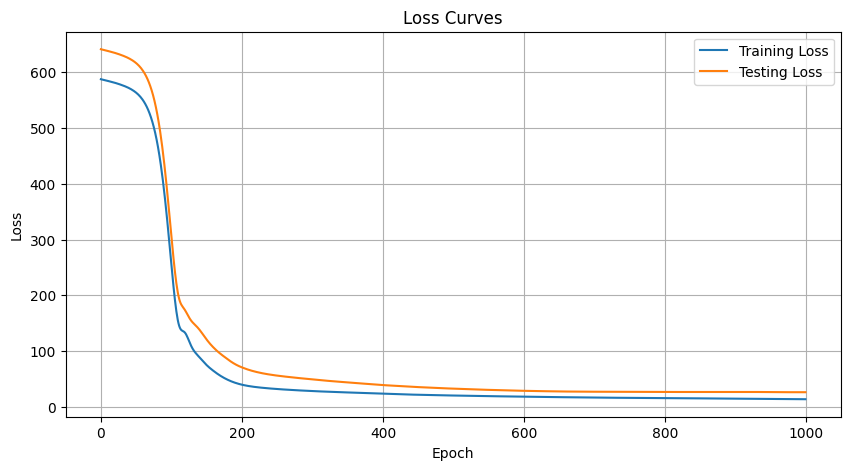

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(n_epoch, np.array(torch.tensor(loss_train).numpy()), label='Training Loss')
plt.plot(n_epoch, np.array(torch.tensor(loss_test).numpy()), label='Testing Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

In [ ]:
with torch.inference_mode():
  y_pred= model(X_test)

In [ ]:
from torchmetrics.regression import R2Score

In [ ]:
r2_metric = R2Score()
r2 = r2_metric(y_pred, Y_test.unsqueeze(dim=1))
print(r2)

tensor(0.7320)


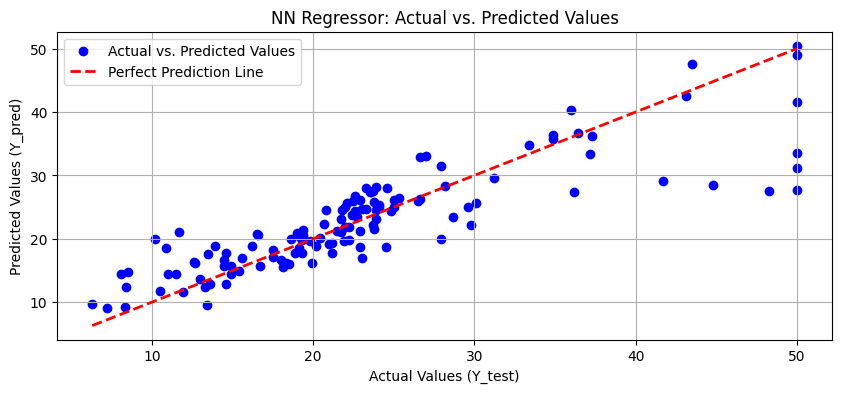

In [ ]:
Y_pred = model(X_test)
plt.figure(figsize=(10,4))
plt.scatter(Y_test.detach().numpy(), Y_pred.detach().numpy(), color='blue', label='Actual vs. Predicted Values')
plt.plot([Y_test.min().detach().numpy(), Y_test.max().detach().numpy()], [Y_test.min().detach().numpy(), Y_test.max().detach().numpy()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('NN Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Y_test)')
plt.ylabel('Predicted Values (Y_pred)')
plt.legend()
plt.grid(True)
plt.show()